In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv('diabetic_data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (101766, 50)

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Drop duplicate patients (keep first encounter only)
df = df.drop_duplicates(subset='patient_nbr', keep='first')

# Create binary readmission column
# 0 = Not Readmitted, 1 = Readmitted
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaned Shape:", df.shape)
print("\nReadmission Value Counts:")
print(df['readmitted'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Cleaned Shape: (71518, 48)

Readmission Value Counts:
readmitted
NO     42985
>30    22240
<30     6293
Name: count, dtype: int64

Missing Values:
race              1948
diag_1              11
diag_2             294
diag_3            1225
max_glu_serum    68062
A1Cresult        58532
dtype: int64


In [3]:
readmit_rate = df['readmitted_binary'].mean() * 100
total_patients = len(df)
total_readmitted = df['readmitted_binary'].sum()

print(f"Total Patients: {total_patients:,}")
print(f"Total Readmitted: {total_readmitted:,}")
print(f"Overall Readmission Rate: {readmit_rate:.2f}%")

Total Patients: 71,518
Total Readmitted: 28,533
Overall Readmission Rate: 39.90%


/tmp/ipython-input-1034/3526373621.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_readmit, x='Age Group', y='Readmission Rate', palette='Blues_d')


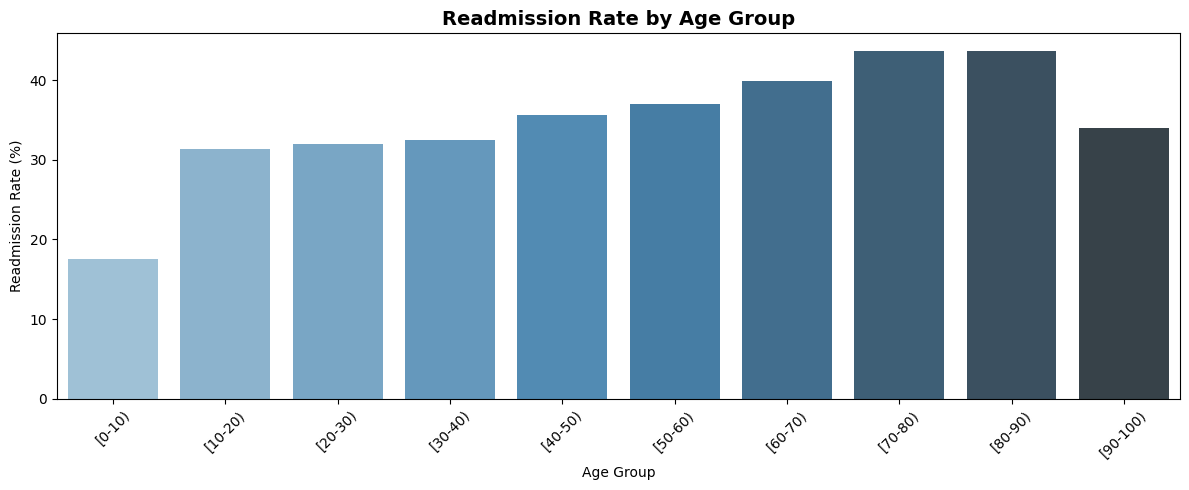

Chart saved!


In [4]:
age_readmit = df.groupby('age')['readmitted_binary'].mean().reset_index()
age_readmit.columns = ['Age Group', 'Readmission Rate']
age_readmit['Readmission Rate'] = age_readmit['Readmission Rate'] * 100

plt.figure(figsize=(12, 5))
sns.barplot(data=age_readmit, x='Age Group', y='Readmission Rate', palette='Blues_d')
plt.title('Readmission Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('readmission_by_age.png', dpi=150)
plt.show()
print("Chart saved!")

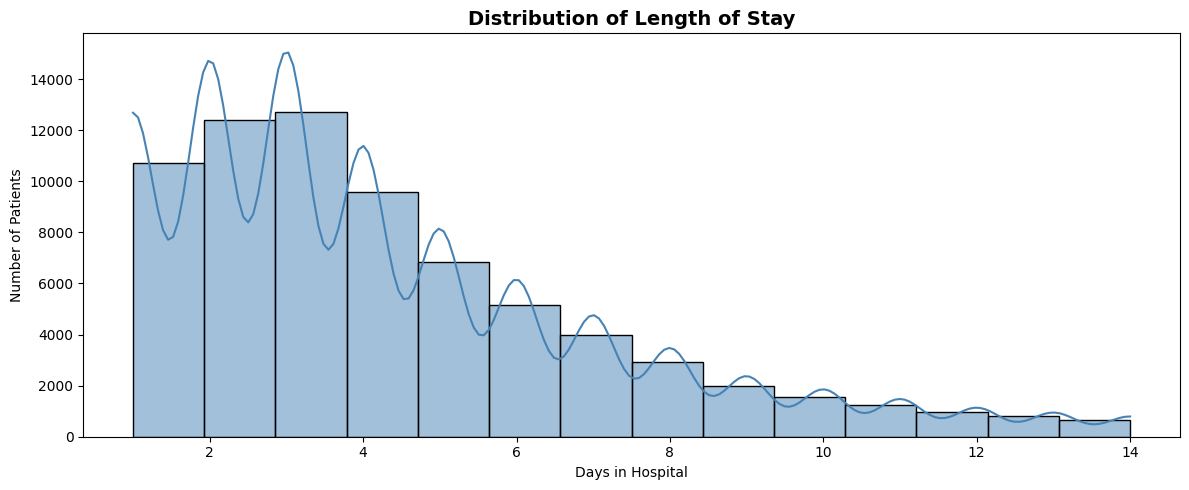

Average Length of Stay: 4.29 days
Max Length of Stay: 14 days
Min Length of Stay: 1 days


In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(df['time_in_hospital'], bins=14, kde=True, color='steelblue')
plt.title('Distribution of Length of Stay', fontsize=14, fontweight='bold')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('length_of_stay.png', dpi=150)
plt.show()

print(f"Average Length of Stay: {df['time_in_hospital'].mean():.2f} days")
print(f"Max Length of Stay: {df['time_in_hospital'].max()} days")
print(f"Min Length of Stay: {df['time_in_hospital'].min()} days")

/tmp/ipython-input-1034/3537965523.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_readmit, x='Diagnosis Code', y='Readmission Rate', palette='Reds_d')


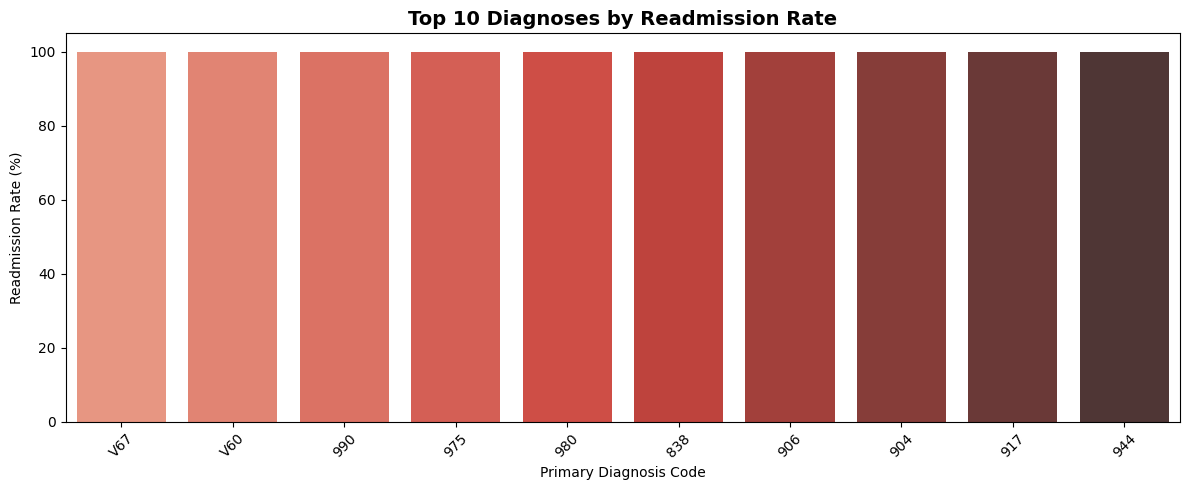

In [6]:
diag_readmit = df.groupby('diag_1')['readmitted_binary'].mean()
diag_readmit = diag_readmit.sort_values(ascending=False).head(10).reset_index()
diag_readmit.columns = ['Diagnosis Code', 'Readmission Rate']
diag_readmit['Readmission Rate'] = diag_readmit['Readmission Rate'] * 100

plt.figure(figsize=(12, 5))
sns.barplot(data=diag_readmit, x='Diagnosis Code', y='Readmission Rate', palette='Reds_d')
plt.title('Top 10 Diagnoses by Readmission Rate', fontsize=14, fontweight='bold')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Primary Diagnosis Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_diagnoses_readmission.png', dpi=150)
plt.show()

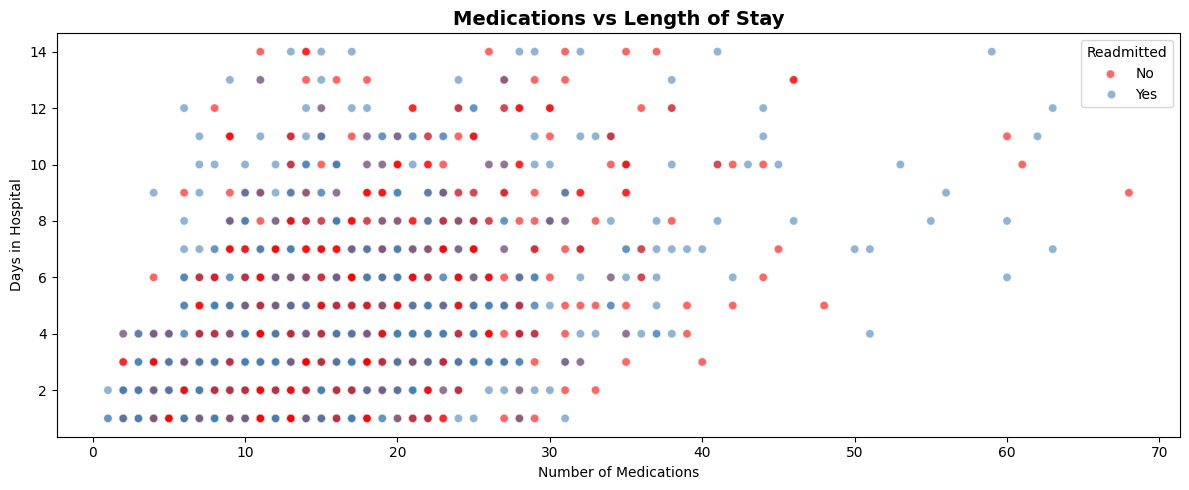

In [7]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df.sample(2000), x='num_medications',
                y='time_in_hospital', hue='readmitted_binary',
                palette={0:'steelblue', 1:'red'}, alpha=0.6)
plt.title('Medications vs Length of Stay', fontsize=14, fontweight='bold')
plt.xlabel('Number of Medications')
plt.ylabel('Days in Hospital')
plt.legend(title='Readmitted', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('medications_vs_los.png', dpi=150)
plt.show()

In [8]:
cohort = df.groupby('age').agg(
    Total_Patients=('patient_nbr', 'count'),
    Avg_LOS=('time_in_hospital', 'mean'),
    Avg_Medications=('num_medications', 'mean'),
    Avg_Diagnoses=('number_diagnoses', 'mean'),
    Readmission_Rate=('readmitted_binary', 'mean')
).reset_index()

cohort['Readmission_Rate'] = (cohort['Readmission_Rate'] * 100).round(2)
cohort['Avg_LOS'] = cohort['Avg_LOS'].round(2)
cohort['Avg_Medications'] = cohort['Avg_Medications'].round(2)
cohort['Avg_Diagnoses'] = cohort['Avg_Diagnoses'].round(2)

print("Cohort Analysis by Age Group:")
print(cohort.to_string(index=False))

Cohort Analysis by Age Group:
     age  Total_Patients  Avg_LOS  Avg_Medications  Avg_Diagnoses  Readmission_Rate
  [0-10)             154     2.60             6.29           2.73             17.53
 [10-20)             535     2.86             7.84           3.76             31.40
 [20-30)            1127     3.46            11.59           5.69             31.94
 [30-40)            2699     3.63            13.63           6.24             32.49
 [40-50)            6878     3.85            14.86           6.71             35.65
 [50-60)           12466     3.98            16.18           7.05             37.00
 [60-70)           15960     4.26            16.88           7.34             39.89
 [70-80)           18210     4.52            16.22           7.50             43.69
 [80-90)           11589     4.80            14.99           7.76             43.73
[90-100)            1900     4.78            13.53           7.79             34.00


/tmp/ipython-input-1034/2855458573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cohort, x='age', y='Avg_LOS', palette='Greens_d')


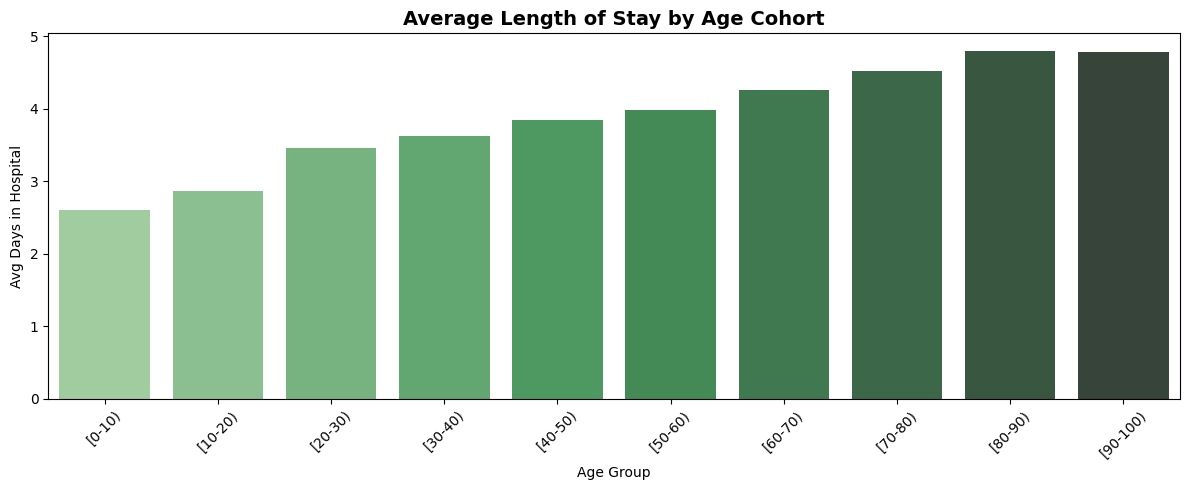

In [9]:
plt.figure(figsize=(12, 5))
sns.barplot(data=cohort, x='age', y='Avg_LOS', palette='Greens_d')
plt.title('Average Length of Stay by Age Cohort', fontsize=14, fontweight='bold')
plt.ylabel('Avg Days in Hospital')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_los_by_age.png', dpi=150)
plt.show()

In [10]:
# HYPOTHESIS 1
# H0: No difference in LOS between high and low diagnosis counts
# H1: Higher diagnosis count leads to longer hospital stays

df['diag_group'] = pd.cut(df['number_diagnoses'],
                           bins=[0, 5, 10, 99],
                           labels=['Low', 'Medium', 'High'])

low_diag = df[df['diag_group'] == 'Low']['time_in_hospital']
high_diag = df[df['diag_group'] == 'High']['time_in_hospital']

t_stat, p_value = stats.ttest_ind(low_diag, high_diag)

print("=" * 50)
print("HYPOTHESIS TEST 1")
print("Does diagnosis count affect length of stay?")
print("=" * 50)
print(f"Low Diagnosis Group  — Avg LOS: {low_diag.mean():.2f} days")
print(f"High Diagnosis Group — Avg LOS: {high_diag.mean():.2f} days")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ RESULT: Statistically Significant")
    print("Higher diagnosis count DOES lead to longer hospital stays")
else:
    print("❌ RESULT: Not Statistically Significant")
print()

# HYPOTHESIS 2
# H0: Readmitted and non-readmitted patients have same number of medications
# H1: Readmitted patients have more medications

readmitted = df[df['readmitted_binary'] == 1]['num_medications']
not_readmitted = df[df['readmitted_binary'] == 0]['num_medications']

t_stat2, p_value2 = stats.ttest_ind(readmitted, not_readmitted)

print("=" * 50)
print("HYPOTHESIS TEST 2")
print("Do readmitted patients have more medications?")
print("=" * 50)
print(f"Readmitted     — Avg Medications: {readmitted.mean():.2f}")
print(f"Not Readmitted — Avg Medications: {not_readmitted.mean():.2f}")
print(f"T-Statistic: {t_stat2:.4f}")
print(f"P-Value: {p_value2:.4f}")
if p_value2 < 0.05:
    print("✅ RESULT: Statistically Significant")
    print("Readmitted patients DO have more medications")
else:
    print("❌ RESULT: Not Statistically Significant")

HYPOTHESIS TEST 1
Does diagnosis count affect length of stay?
Low Diagnosis Group  — Avg LOS: 3.34 days
High Diagnosis Group — Avg LOS: 5.12 days
T-Statistic: -5.9774
P-Value: 0.0000
✅ RESULT: Statistically Significant
Higher diagnosis count DOES lead to longer hospital stays

HYPOTHESIS TEST 2
Do readmitted patients have more medications?
Readmitted     — Avg Medications: 16.05
Not Readmitted — Avg Medications: 15.47
T-Statistic: 9.1366
P-Value: 0.0000
✅ RESULT: Statistically Significant
Readmitted patients DO have more medications


In [11]:
# Save cleaned dataset
df.to_csv('diabetic_cleaned.csv', index=False)

# Save cohort summary
cohort.to_csv('cohort_summary.csv', index=False)

print("✅ Files Saved:")
print("   - diabetic_cleaned.csv")
print("   - cohort_summary.csv")
print("   - readmission_by_age.png")
print("   - length_of_stay.png")
print("   - top_diagnoses_readmission.png")
print("   - medications_vs_los.png")
print("   - avg_los_by_age.png")
print()
print("✅ Analysis Complete!")

✅ Files Saved:
   - diabetic_cleaned.csv
   - cohort_summary.csv
   - readmission_by_age.png
   - length_of_stay.png
   - top_diagnoses_readmission.png
   - medications_vs_los.png
   - avg_los_by_age.png

✅ Analysis Complete!


In [12]:
import pandas as pd
import sqlite3

# Load cleaned data
df = pd.read_csv('diabetic_cleaned.csv')

# Create in-memory SQL database
conn = sqlite3.connect(':memory:')
df.to_sql('diabetic_cleaned', conn, index=False, if_exists='replace')

print("✅ Database created successfully!")

✅ Database created successfully!


In [13]:
query1 = """
SELECT
    age,
    COUNT(*) AS total_patients,
    SUM(readmitted_binary) AS total_readmitted,
    ROUND(SUM(readmitted_binary) * 100.0 / COUNT(*), 2) AS readmission_rate
FROM diabetic_cleaned
GROUP BY age
ORDER BY readmission_rate DESC;
"""
result1 = pd.read_sql_query(query1, conn)
print("QUERY 1 — Readmission Rate by Age Group")
print(result1.to_string(index=False))

QUERY 1 — Readmission Rate by Age Group
     age  total_patients  total_readmitted  readmission_rate
 [80-90)           11589              5068             43.73
 [70-80)           18210              7956             43.69
 [60-70)           15960              6366             39.89
 [50-60)           12466              4613             37.00
 [40-50)            6878              2452             35.65
[90-100)            1900               646             34.00
 [30-40)            2699               877             32.49
 [20-30)            1127               360             31.94
 [10-20)             535               168             31.40
  [0-10)             154                27             17.53


In [14]:
query2 = """
SELECT
    diag_1,
    COUNT(*) AS patient_count,
    ROUND(AVG(time_in_hospital), 2) AS avg_los,
    ROUND(AVG(num_medications), 2) AS avg_medications
FROM diabetic_cleaned
GROUP BY diag_1
ORDER BY avg_los DESC
LIMIT 20;
"""
result2 = pd.read_sql_query(query2, conn)
print("QUERY 2 — Avg Length of Stay by Diagnosis")
print(result2.to_string(index=False))

QUERY 2 — Avg Length of Stay by Diagnosis
diag_1  patient_count  avg_los  avg_medications
   145              1    13.00            32.00
    10              1    12.00            32.00
    48              2    11.50            24.50
   208              4    11.25            17.75
   720              1    11.00            24.00
   114              1    11.00            41.00
   V43              1    10.00            15.00
   133              1    10.00            13.00
   201              6     9.67            21.67
   862              2     9.50            19.00
   324              2     9.50            21.50
   323             10     9.30            18.30
   649              1     9.00            20.00
    31              2     9.00            24.50
   170              2     9.00            19.50
   510             24     8.63            24.13
   551              5     8.40            22.20
   161             11     8.27            14.36
   V57            659     8.26            14.5

In [15]:
query3 = """
SELECT
    patient_nbr,
    age,
    time_in_hospital,
    number_diagnoses,
    num_medications,
    readmitted
FROM diabetic_cleaned
WHERE time_in_hospital > 7
AND number_diagnoses > 7
AND readmitted_binary = 1
ORDER BY time_in_hospital DESC;
"""
result3 = pd.read_sql_query(query3, conn)
print("QUERY 3 — High Risk Patients")
print(result3.to_string(index=False))

QUERY 3 — High Risk Patients
 patient_nbr      age  time_in_hospital  number_diagnoses  num_medications readmitted
     6915888  [70-80)                14                 8               19        <30
      541134  [70-80)                14                 9               33        >30
     1147545  [70-80)                14                 9               32        >30
   101398734  [70-80)                14                 9               18        >30
     7991397  [80-90)                14                 9               35        >30
     2728458  [50-60)                14                 9               29        >30
     1144719  [30-40)                14                 9               27        >30
     4876191  [80-90)                14                 9               14        >30
      231237  [80-90)                14                 9               27        >30
     8812899  [70-80)                14                 9               20        >30
   106752348  [30-40)    

In [16]:
query4 = """
SELECT
    COUNT(*) AS total_patients,
    ROUND(AVG(time_in_hospital), 2) AS avg_los,
    ROUND(AVG(num_medications), 2) AS avg_medications,
    ROUND(SUM(readmitted_binary) * 100.0 / COUNT(*), 2) AS readmission_rate
FROM diabetic_cleaned;
"""
result4 = pd.read_sql_query(query4, conn)
print("QUERY 4 — Overall KPI Summary")
print(result4.to_string(index=False))

QUERY 4 — Overall KPI Summary
 total_patients  avg_los  avg_medications  readmission_rate
          71518     4.29            15.71              39.9
